In [112]:
import numpy as np
import uproot as up

import matplotlib.pyplot as plt

In [113]:
f1=up.open("../voxelstudy/Results_100k_17-3Voxel_Comparison_wires.root")


In [181]:
isSafeFiles=False
def Plot2D_JointPlot(valO,ValG4,FileName,Title,Binsize=200,histBin=500,isPlottext=False,isHistType="numpy"):
    maXX=np.max(np.array([np.max(ValG4[0]),np.max(valO[0])]))
    miNX=np.min(np.array([np.min(ValG4[0]),np.min(valO[0])]))
    lins1X=np.linspace(miNX,maXX,Binsize)
    
    maXY=np.max(np.array([np.max(ValG4[1]),np.max(valO[1])]))
    miNY=np.min(np.array([np.min(ValG4[1]),np.min(valO[1])]))
    lins1Y=np.linspace(miNY,maXY,Binsize)
    
    G4Dict={"x(mm)":ValG4[0],"y(mm)":ValG4[1]}
    OpticksDict={"x(mm)":valO[0],"y(mm)":valO[1]}
    plt.figure(figsize=(15,15),dpi=300)
    g=sns.jointplot(data=G4Dict,x="x(mm)", y="y(mm)", kind='hist',bins=[lins1X,lins1Y],marginal_kws={"bins":lins1X,"kde":True},cmap="viridis",color="green",height=10,cbar=True,cbar_kws={"use_gridspec":False, "location":"top","aspect":50,"fraction":0.016,"pad":0,"aspect":50});
    #plt.hist2d(ValG4[0], ValG4[1], bins=[lins1X,lins1Y], cmap="viridis",norm=LogNorm());
    x=0
    y=0
    fitx=0
    fity=0
    g.ax_joint.tick_params(axis='both', which='major', labelsize=25) 
    g.ax_joint.set_xlabel("x (mm)",fontsize=25)
    g.ax_joint.set_ylabel("y (mm)",fontsize=25)
    if(isPlottext):
        binX=np.linspace(np.min(ValG4[0]),np.max(ValG4[0]),histBin)
        binY=np.linspace(np.min(ValG4[1]),np.max(ValG4[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(ValG4[0], bins=binX)
            y=np.histogram(ValG4[1], bins=binY)
            fitx=FitHist1D(x,None,"x","blue",0.5)
            fity=FitHist1D(y,None,"y","red",0.5)
        else:
            x=np.histogram(ValG4[0], bins=binX)
            y=np.histogram(ValG4[1], bins=binY)
            x=plt.hist(ValG4[0], bins=lins1X)
            y=np.histogram(ValG4[1], bins=lins1Y)
            fitx=FitHist1D(x,plt,"x","blue",0.5)
            fity=FitHist1D(y,plt,"y","red",0.5)
            plt.xlim(-5,5)
        g.ax_marg_x.axvspan(fitx["u"] - fitx["sigma"],fitx["u"] + fitx["sigma"], color='gray', alpha=0.35)

        g.ax_marg_y.axhspan(fity["u"] - fity["sigma"], fity["u"] + fity["sigma"], color='gray', alpha=0.35)
        g.refline(x=fitx["u"], y=fity["u"], color='green', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        #print(x_mean,x_std)
        XMean=fitx["u"]
        YMean=fity["u"]
        Xsig=fitx["sigma"]
        Ysig=fity["sigma"]
        labelX_str=r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(XMean+ 2*Xsig, np.mean(Ydata), labelX_str, fontsize=20)
        ax_marg_y.text( np.mean(Xdata),YMean + 2*Ysig, labelY_str, fontsize=20)
        
    
    #g.plot_joint(sns.kdeplot, color="red", zorder=0, alpha=0.3,levels=6)
    #g.plot_marginals(sns.rugplot,  color="red", height=+.02, clip_on=False)
    plt.suptitle(Title[1],fontweight="bold",ha="right",fontsize=25)
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[1]}.png")
        
    g=sns.jointplot(data=OpticksDict,x="x(mm)",y= "y(mm)" ,kind='hist',cmap="viridis",bins=[lins1X,lins1Y],marginal_kws={"bins":Binsize,"kde":True},color="red",height=10,cbar=True,cbar_kws={"use_gridspec":True,"fraction":0.016,"pad":0,"location":"top","aspect":50});
    g.ax_joint.tick_params(axis='both', which='major', labelsize=25)    
    g.ax_joint.set_xlabel("x (mm)",fontsize=25)
    g.ax_joint.set_ylabel("y (mm)",fontsize=25)
    #g.plot_joint(sns.kdeplot,  color="green",alpha=0.3, zorder=0, levels=6)
    #g.plot_marginals(sns.rugplot,  color="green", height=+.02, clip_on=False)
    #plt.hist2d(valO[0], valO[1], bins=[lins1X,lins1Y], cmap="viridis",norm=LogNorm());
    x=0
    y=0
    fitx=0
    fity=0
    if(isPlottext):
        binX=np.linspace(np.min(valO[0]),np.max(valO[0]),histBin)
        binY=np.linspace(np.min(valO[1]),np.max(valO[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,None,"x","red",0.5)
            fity=FitHist1D(y,None,"y","green",0.5)
        else:
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,plt,"x","red",0.5)
            fity=FitHist1D(y,plt,"y","green",0.5)
            plt.xlim(-5,5)


        
        g.ax_marg_x.axvspan(fitx["u"] - fitx["sigma"],fitx["u"] + fitx["sigma"], color='gray', alpha=0.35)

        g.ax_marg_y.axhspan(fity["u"] - fity["sigma"], fity["u"] + fity["sigma"], color='gray', alpha=0.35)
        g.refline(x=fitx["u"], y=fity["u"], color='red', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        #print(x_mean,x_std)
        XMean=fitx["u"]
        YMean=fity["u"]
        Xsig=fitx["sigma"]
        Ysig=fity["sigma"]
        labelX_str=r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(XMean+ 2*Xsig, np.mean(Ydata), labelX_str, fontsize=20)
        ax_marg_y.text( np.mean(Xdata),YMean + 2*Ysig, labelY_str, fontsize=20)
    
    plt.suptitle(Title[0],fontweight="bold",ha="right",fontsize=25)
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")
    del g
    
def Plot1D_KDE(valO,ValG4,FileName,Title,Binsize=200,labelx="x",isPlottext=False,isHistType="numpy",opacity=1,fontsize=30,width=5,lbls=["Geant4","Opticks"],tp="diff",isLog=False,ylim=[-1,1],xlim=[0,500],Ylabel="Frequency"):
    maXX = np.max(np.array([np.max(ValG4),np.max(valO)]))
    miNX = np.min(np.array([np.min(ValG4),np.min(valO)]))
    lins1X = np.linspace(miNX,maXX,Binsize)
    fig, ax = plt.subplots(2, 1, figsize=(25, 15), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    x = 0
    y = 0
    if(isPlottext):
        if(isHistType=="numpy"):
            x = np.histogram(ValG4, bins=lins1X)
        else:
            x = plt.hist(ValG4, bins=lins1X)
        h1=ax[0].hist(ValG4,color="red",label=lbls[0],bins=lins1X,histtype="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
    else:
        #sns.histplot(data=G4Dict,x=lbl,color="orange",label="Geant4",bins=Binsz,kde=False,element="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
        h1=ax[0].hist(ValG4,color="red",label=lbls[0],bins=lins1X,histtype="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
    
    x=0
    y=0
    fitx=0
    fity=0
    
    if(isPlottext):
        binX = np.linspace(np.min(valO[0]) , np.max(valO[0]) , Binsize)
        if(isHistType=="numpy"):
            x = np.histogram(valO[0], bins=binX)
        else:
            x = np.histogram(valO[0], bins=binX)
        h2=ax[0].hist(valO,color="green",label=lbls[1],bins=lins1X,histtype="step",fill=False,linestyle="--",linewidth=width,alpha=opacity);
    else:    
        #sns.histplot(data=OpticksDict,x=lbl,color="blue",label="Opticks",bins=Binsz,kde=False,element="step",fill=False,linestyle="--",linewidth=width,alpha=opacity)
        h2=ax[0].hist(valO,color="green",label=lbls[1],bins=lins1X,histtype="step",fill=False,linestyle="--",linewidth=width,alpha=opacity);

    #Ratio Plot    
    # Calculate histogram counts for ratio plot - MUST use same bins
    counts1,bin_edges,_ = h1
    counts2,_,_ = h2 # Use the same bin_edges

    # Calculate bin centers for plotting the ratio
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    numerator_val = 0
    combinedarray = 0
    denominator_val = 0
    result=[]
    res_err=[]
    label=""
    ylabel=""
    xlabel=""
   
    
    if(tp == "diff"):
        label="Mean Normalized Difference"
        ylabel="2*(O-G)/(O+G)"
        xlabel=labelx
        numerator_val = counts2 - counts1
        combinedarray = np.concatenate((counts1, counts2))
        denominator_val = (counts1+counts2)*0.5
        
        eps = 1e-12
        numerator_val = np.where(np.abs(numerator_val) < eps, eps, numerator_val)
        denominator_val = np.where(np.abs(denominator_val) < eps, eps, denominator_val)
        result  = numerator_val / denominator_val
        error_numerator = np.sqrt(counts1 + counts2)
        error_denominator = 0.5*np.sqrt(counts1+counts2) # <-- The error from the value you divide by
        res_err = np.abs(result) * np.sqrt((error_numerator / numerator_val)**2 +(error_denominator / denominator_val)**2)        
    elif( tp == "ratio"):
        label="Ratio G4/Opticks"
        ylabel="Ratio"
        xlabel=labelx
        # Poisson errors (or replace with your own errors)
        err1 = np.sqrt(counts1)
        err2 = np.sqrt(counts2)

        # ratio
        result  = counts2 / counts1
        # propagated error
        res_err = result * np.sqrt((err2 / counts2)**2 + (err1 / counts1)**2)
    elif(tp == "sig"):
        label="Significance"
        ylabel="(O-G)/sqrt(O+B)"
        xlabel=labelx
        A = counts1
        B = counts2

        # significance numerator and denominator
        numerator = B - A
        denominator = np.sqrt(A + B)
        
        # avoid division by zero
        eps = 1e-12
        denominator = np.where(denominator < eps, eps, denominator)
        
        # significance metric
        result = numerator / denominator
        
        # error on significance (optional)
        # dS = sqrt( (σ_num/den)^2 + (num * σ_den / den^2)^2 )
        # where σ_num = sqrt(A+B), σ_den = (A+B)^(-1/2) * 0.5
        
        sigma_num = np.sqrt(A + B)
        sigma_den = 0.5 / np.sqrt(A + B + eps)
        
        res_err = np.sqrt(
            (sigma_num / denominator)**2 +
            (numerator * sigma_den / (denominator**2))**2
        )
    elif(tp=="sfd"):
        label="Symmetric Fractional Difference"
        ylabel="2*(O-G)/A+B"
        A = counts1
        B = counts2
        
        eps = 1e-12
        den = A + B
        den = np.where(den < eps, eps, den)
        
        # symmetrized fractional difference
        result = 2 * (B - A) / den
        
        # error
        res_err = 4 * np.sqrt(A * B) / (den**1.5)

        
        
        
    if(len(result)<1):
        print (f"Check type {tp}, vector does not have any element")
        return
 
    #error_numerator = np.sqrt(counts1 + counts2)
    #error_denominator = np.sqrt(counts1) # <-- The error from the value you divide by
    
  

    # Use scientific notation for the axis 
    ax[0].ticklabel_format(axis='y', style='sci', scilimits=(4,4))
    ax[0].tick_params(axis='both',which="major",labelsize=fontsize+10)
    ax[1].tick_params(axis='both',which="major",labelsize=fontsize+10)


    ax[0].set_ylabel(Ylabel,fontsize=fontsize+10)
    #ax[0].set_xlabel(lbl,fontsize=fontsize+10)
    ax[0].yaxis.get_offset_text().set_size(fontsize+10) # Adjust the font size here
   
    ax[0].legend(fontsize=fontsize,loc="lower center")
    ax[0].set_title(Title,fontweight="bold",ha="center",fontsize=fontsize+20)
    if(isLog):
        ax[0].semilogy()
    
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")
    
    print (f" Size Bin_Centers is {len(bin_centers)}")
    print (f" Size result {len(result)} min, max {np.max(result)} , {np.min(result)}")    
    print (f" Size res_err {len(res_err)} min, max {np.max(res_err)} , {np.min(res_err)}")    
    
    #ax[1].plot(bin_centers, ratio, marker='o', linestyle='-', color='black', markersize=5)
    ax[1].errorbar(bin_centers, result, yerr=res_err, fmt='o', color='black',
                    markersize=5, capsize=3, elinewidth=1, label=label) # fmt='o' for points
    if(len(ylim)>1):
        ax[1].set_ylim(ylim[0],ylim[1])
    if(len(xlim)>1):
        ax[1].set_xlim(xlim[0],xlim[1])
    ax[1].axhline(1, color='grey', linestyle='--', linewidth=1)
    ax[1].set_xlabel(xlabel,fontsize=fontsize+10)
    ax[1].set_ylabel(ylabel,fontsize=(fontsize+10))
    ax[1].grid(True, linestyle=':', alpha=0.6)
    #ax[1].set_ylim(-np.max(res_err),np.max(res_err))
    #print(f"result {result}")
    #print(f"res_err {res_err}")
    #ax[1].semilogy()
    #ax[1].ticklabel_format(axis='y', style='sci', scilimits=(0.01,0.01))
    ax[1].tick_params(axis='both',which="major",labelsize=fontsize+10)
    print(f" Max G4 {np.max(counts1)} O {np.max(counts2)}")
    print(f" Min G4 {np.min(counts1)} O {np.min(counts2)}")    
    
def FitHist1D(hist,ax,label,clr,ap,width=3,linstyle="-"):
    ## Locate Min and Max
    MinAndMaxMask=(hist[0]>=(np.mean(hist[0])*0.1)) & (hist[0]<=np.max(hist[0])*0.9)
    
    initials=(np.max(hist[0]),np.mean(hist[1][:-1][MinAndMaxMask]),np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    #initials=(np.max(hist[0]),0,np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    print(f"Initials {initials}")
    fit=scp.curve_fit(Gauss1DSkew,hist[1][:-1],hist[0],p0=initials,maxfev=5000)
    String_=label+r'$\bar{X}$'+f"={round(fit[0][1],2)}," + r'$\sigma$' +f"= {abs(round(fit[0][2],2))}"
    #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
    if(ax):
        ax.plot(hist[1][:-1],Gauss1DSkew(hist[1][:-1],*fit[0]),label=String_,color=clr,linestyle=linstyle,alpha=ap,linewidth=width)
    FitValues={"Amp":round(fit[0][0],2),"u":round(fit[0][1],2),"sigma":abs(round(fit[0][2],2)),"offset":round(fit[0][3],2)}
    print(FitValues)
    return FitValues    

In [115]:
Opticks=f1["OpticksHits"]
G4=f1["Geant4Hits"]

In [116]:
f1.keys()

['generator;1', 'OpticksHits;1', 'Geant4Hits;1', 'PhotonInfo;1']

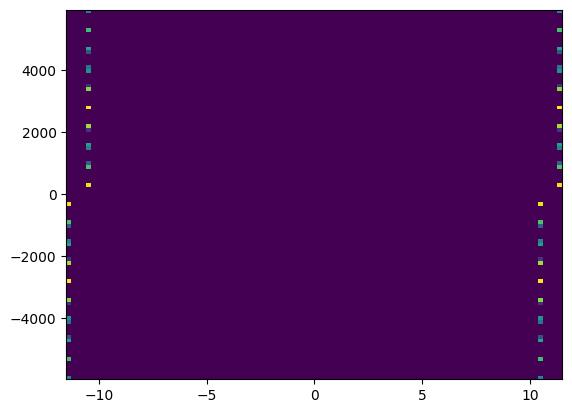

In [117]:
_=plt.hist2d(Opticks["x"].array().to_numpy(),Opticks["y"].array().to_numpy(),bins=100)


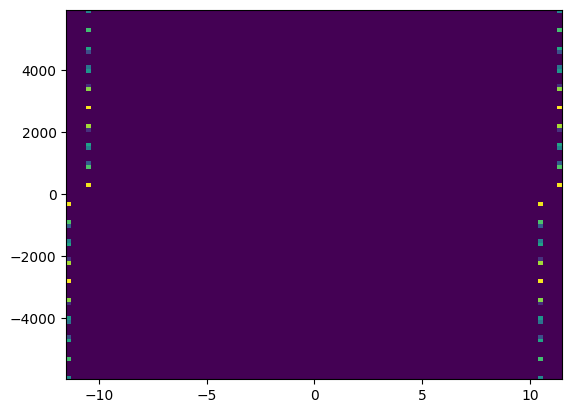

In [118]:
_=plt.hist2d(G4["x"].array().to_numpy(),G4["y"].array().to_numpy(),bins=100)

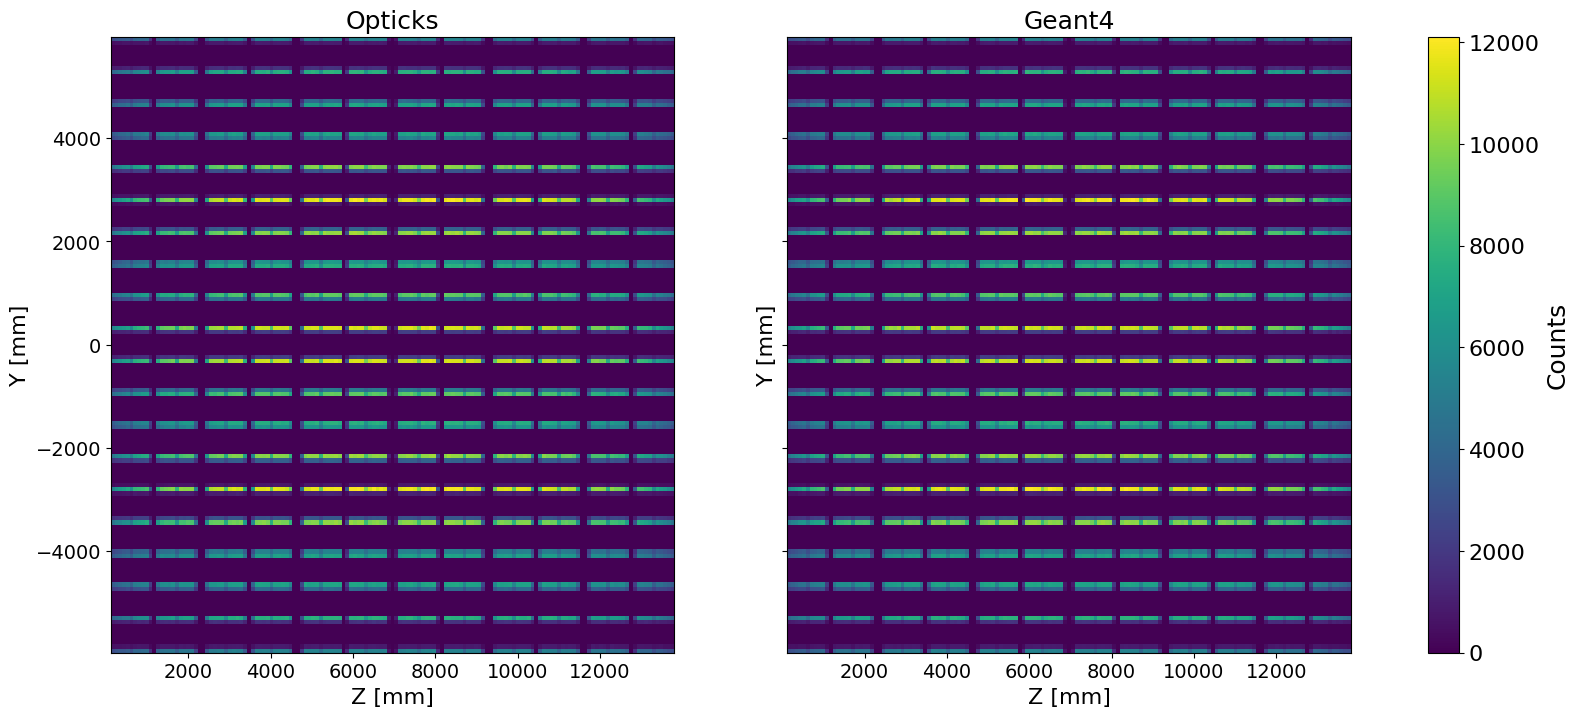

In [119]:
bins=150
ZG4 = G4["z"].array().to_numpy()
ZO = Opticks["z"].array().to_numpy()
YG4 = G4["y"].array().to_numpy()
YO = Opticks["y"].array().to_numpy()
xmin = min(ZG4.min(), ZO.min())
xmax = max(ZG4.max(), ZO.max())
xbins = np.linspace(xmin, xmax, bins)
ymin = min(YG4.min(), YO.min())
ymax = max(YG4.max(), YO.max())
ybins = np.linspace(ymin, ymax, bins)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 8),sharex=True,sharey=True)
h1=axs[0].hist2d(G4["z"].array().to_numpy(),G4["y"].array().to_numpy(),bins=[xbins,ybins])
h2=axs[1].hist2d(Opticks["z"].array().to_numpy(),Opticks["y"].array().to_numpy(),bins=[xbins,ybins])

# Shared colorbar
cbar = fig.colorbar(h1[3], ax=axs, orientation='vertical')
cbar.set_label("Counts", fontsize=18)       # colorbar label font size
cbar.ax.tick_params(labelsize=16)           # colorbar tick font size

# Axis labels and titles with larger font
axs[0].set_title("Opticks", fontsize=18)
axs[1].set_title("Geant4", fontsize=18)
for ax in axs:
    ax.set_xlabel("Z [mm]", fontsize=16)
    ax.set_ylabel("Y [mm]", fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)

/tmp/rice/opticks/ipykernel_1280218/1088615470.py:2: RuntimeWarning: invalid value encountered in divide
  k = h2[0] / h1[0]


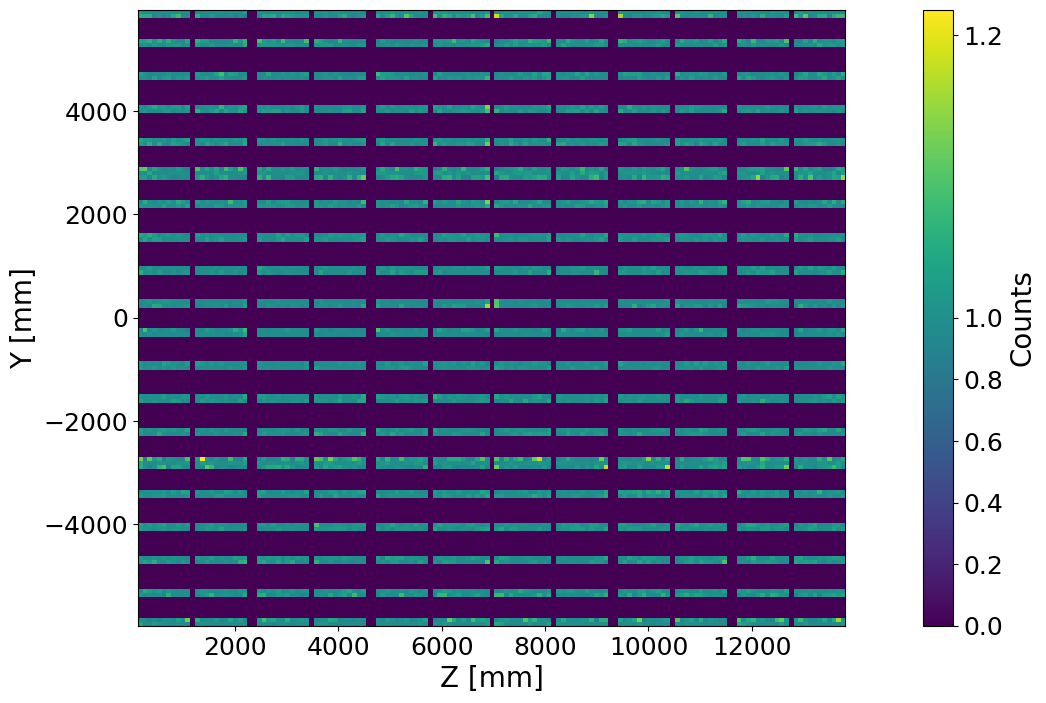

In [159]:
from matplotlib.colors import TwoSlopeNorm
k = h2[0] / h1[0]
k = np.nan_to_num(k, nan=0.0, posinf=0.0, neginf=0.0)
plt.figure(figsize=(20, 8))
#plt.title("Ratio (Opticks/G4)", fontsize=18)
xedges = h1[1]   # x bin edges from hist2d
yedges = h1[2]   # y bin edges from hist2d
im = plt.imshow(np.rot90(np.flip(k, axis=1)),    origin="lower",
    cmap="viridis",   # diverging colormap
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],            
    norm=TwoSlopeNorm(vcenter=1, vmin=0, vmax=np.max(k))  # center at 1
)
cbar = plt.colorbar(im)
cbar.set_label("Counts", fontsize=20)       # label font size
cbar.ax.tick_params(labelsize=18)           # tick font size

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.xlabel("Z [mm]", fontsize=20)
plt.ylabel("Y [mm]", fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.show()   

 Size Bin_Centers is 49
 Size result 49 min, max nan , nan
 Size res_err 49 min, max nan , nan
 Max G4 15034296.0 O 15047492.0
 Min G4 0.0 O 0.0


/tmp/rice/opticks/ipykernel_1280218/2435515886.py:196: RuntimeWarning: divide by zero encountered in divide
  result  = counts2 / counts1
/tmp/rice/opticks/ipykernel_1280218/2435515886.py:196: RuntimeWarning: invalid value encountered in divide
  result  = counts2 / counts1
/tmp/rice/opticks/ipykernel_1280218/2435515886.py:198: RuntimeWarning: invalid value encountered in divide
  res_err = result * np.sqrt((err2 / counts2)**2 + (err1 / counts1)**2)


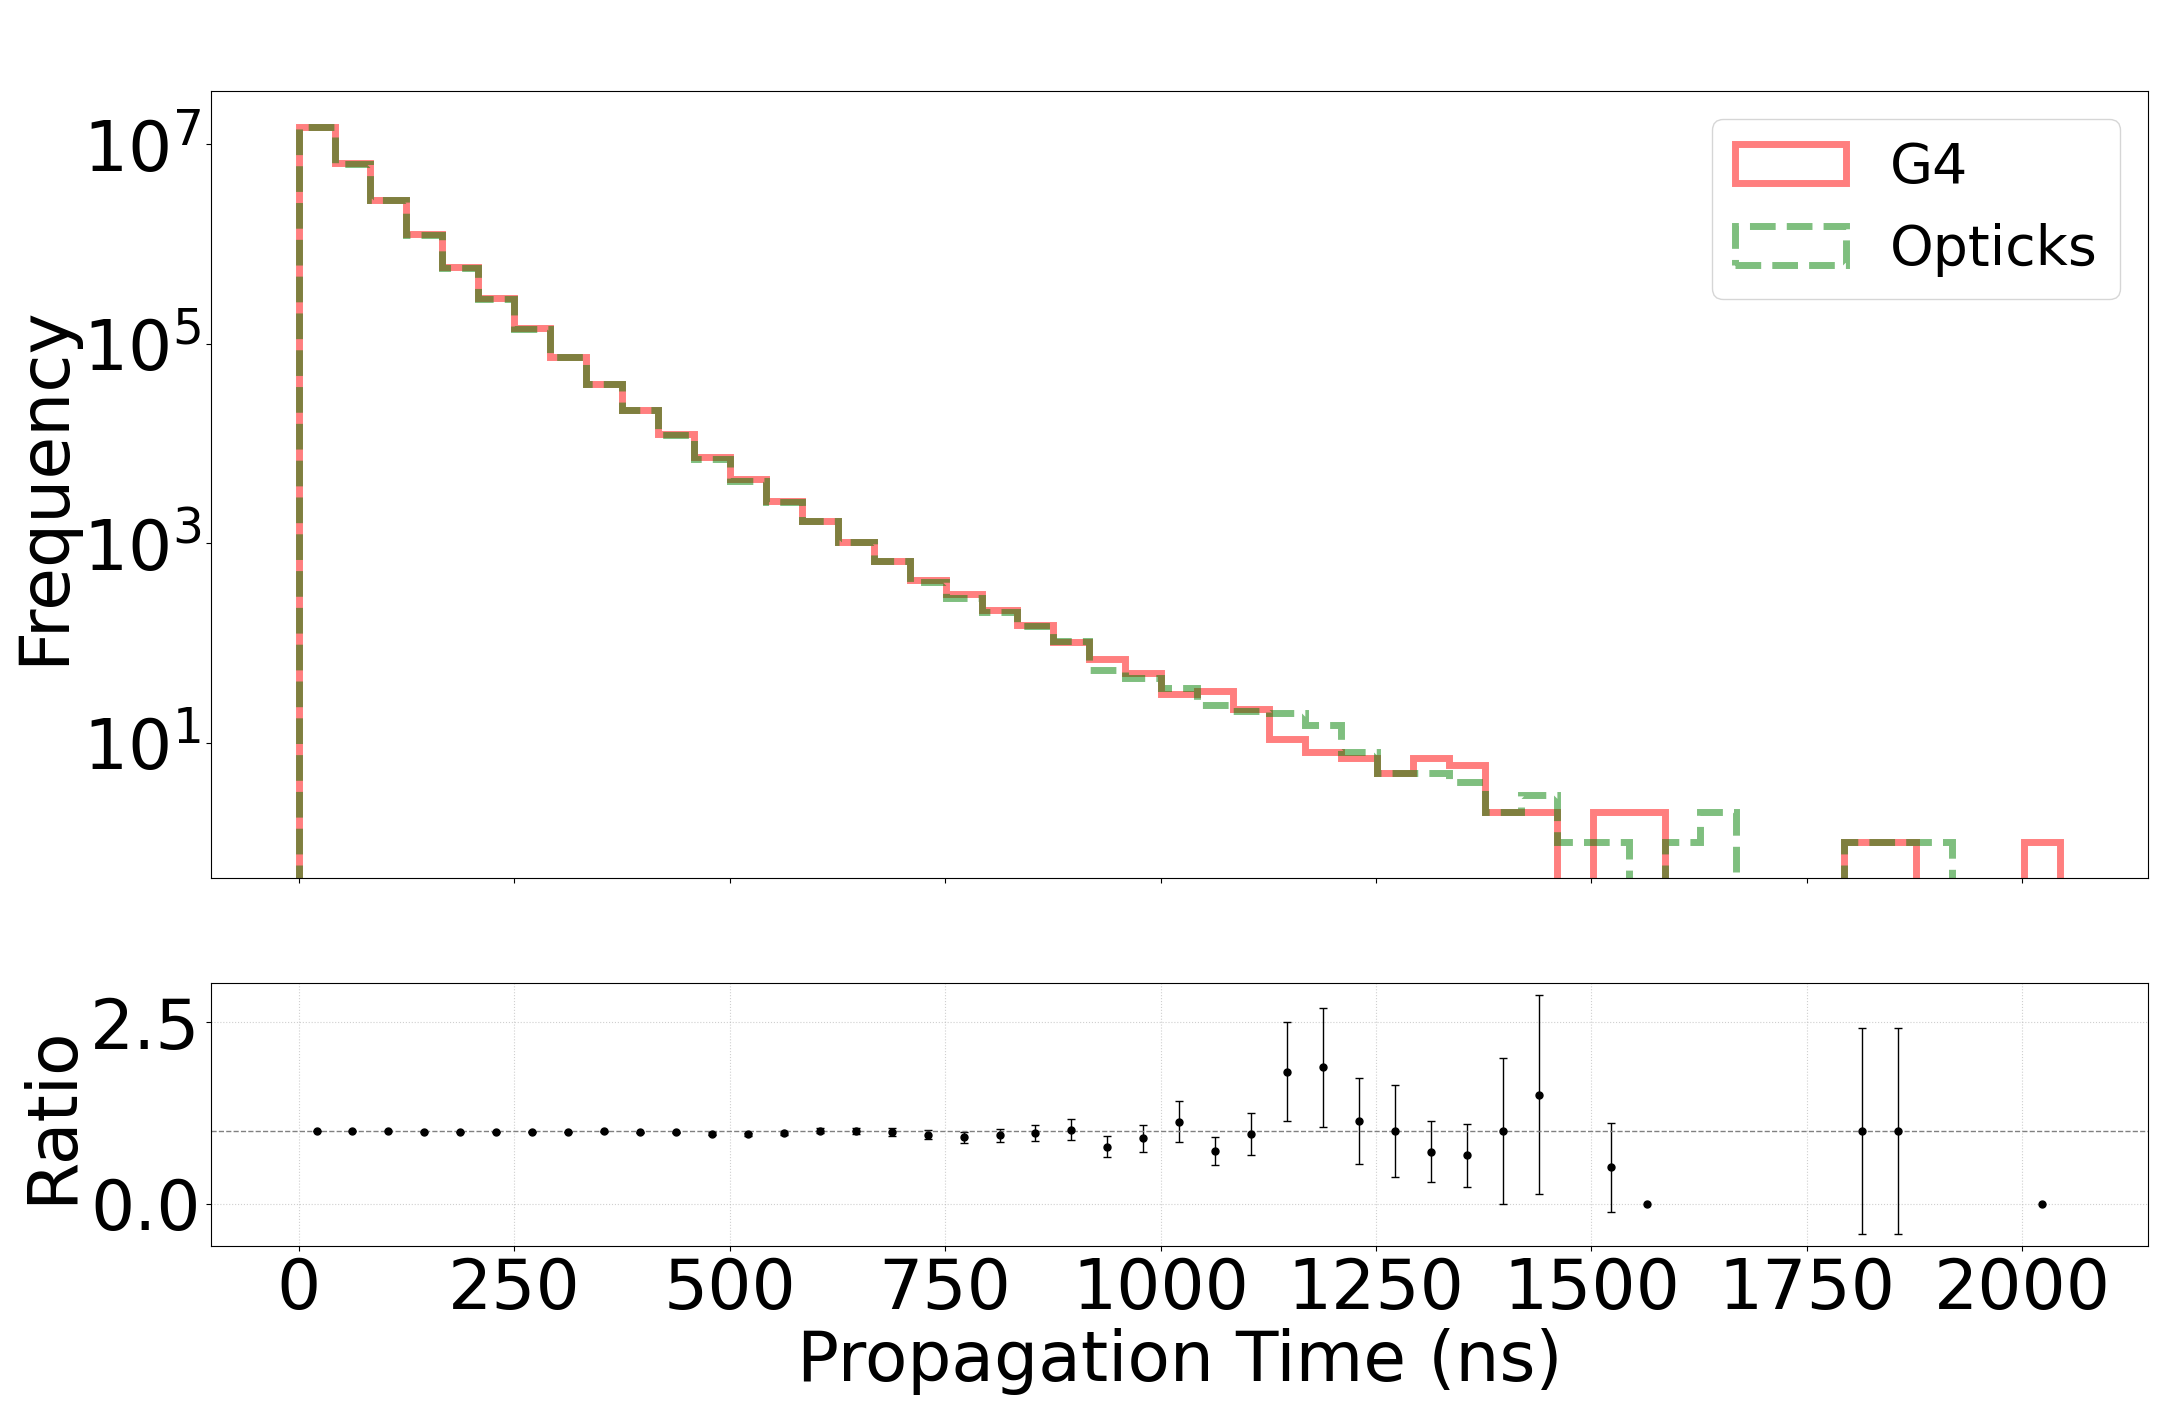

In [163]:
G4Time = G4["t"].array().to_numpy()
OpticksTime = Opticks["t"].array().to_numpy()
_=Plot1D_KDE(OpticksTime,G4Time,"Time_Comparison"," ",Binsize=50,labelx="Propagation Time (ns)",isPlottext=False,isHistType="",opacity=0.5,fontsize=40,width=5,lbls=["G4","Opticks"],tp="ratio",isLog=True,xlim=[],ylim=[])



xmin = min(a.min(), b.min())
xmax = max(a.max(), b.max())
xbins = np.linspace(xmin, xmax, 300)

plt.hist(a,bins=xbins,label="G4",histtype="step",color="red")
plt.hist(b,bins=xbins,label="Opticks",histtype="step",color="green")
plt.xlim(-5,500)
plt.legend()
plt.show()


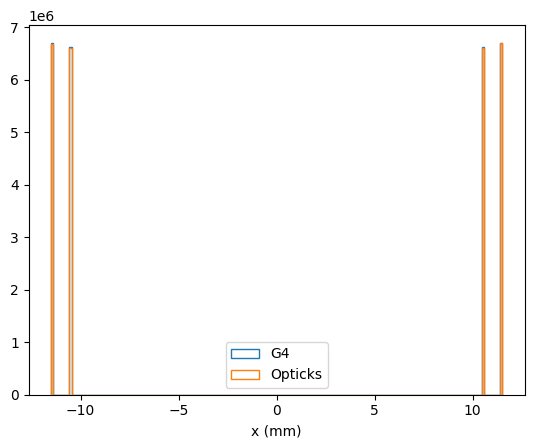

In [122]:

a = G4["x"].array().to_numpy()
b = Opticks["x"].array().to_numpy()
xmin = min(a.min(), b.min())
xmax = max(a.max(), b.max())
xbins = np.linspace(xmin, xmax, 200)

plt.hist(a,bins=xbins,label="G4",histtype="step")
plt.hist(b,bins=xbins,label="Opticks",histtype="step")
plt.xlabel("x (mm)")
plt.legend()


plt.show()


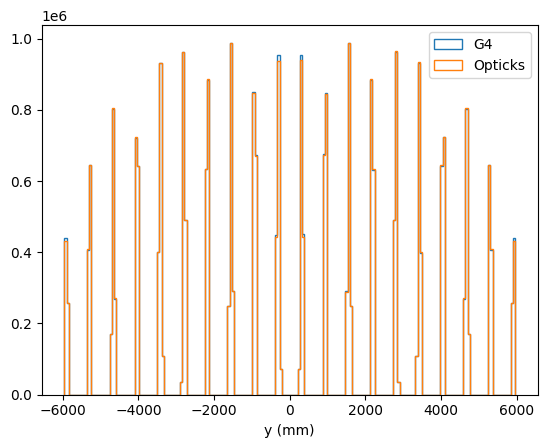

In [123]:

a = G4["y"].array().to_numpy()
b = Opticks["y"].array().to_numpy()
xmin = min(a.min(), b.min())
xmax = max(a.max(), b.max())
xbins = np.linspace(xmin, xmax, 200)

plt.hist(a,bins=xbins,label="G4",histtype="step")
plt.hist(b,bins=xbins,label="Opticks",histtype="step")
plt.legend()
plt.xlabel("y (mm)")
plt.show()


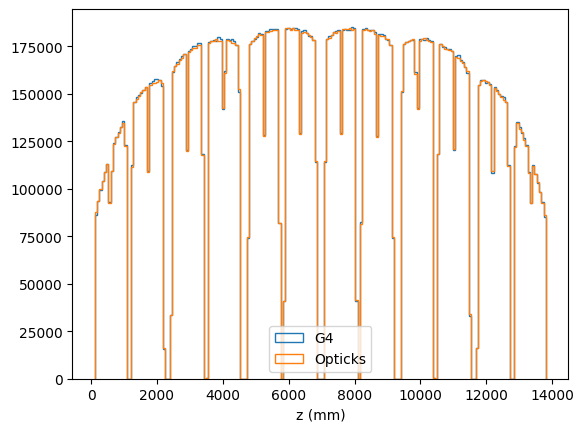

In [124]:

a = G4["z"].array().to_numpy()
b = Opticks["z"].array().to_numpy()
xmin = min(a.min(), b.min())
xmax = max(a.max(), b.max())
xbins = np.linspace(xmin, xmax, 200)



plt.hist(a,bins=xbins,label="G4",histtype="step")
plt.hist(b,bins=xbins,label="Opticks",histtype="step")
plt.xlabel("z (mm)")
plt.legend()

plt.show()


In [125]:
G4.keys()

['evtID',
 'SensorID',
 'SensorName',
 'x',
 'y',
 'z',
 't',
 'wavelength',
 'ProcessID']

In [126]:
f1["PhotonInfo"].keys()

['G4ScintPhotons',
 'G4CernPhotons',
 'OScintPhotons',
 'OCerenkovPhotons',
 'Time',
 'eventID',
 'BatchID']

In [127]:
f1["PhotonInfo/eventID"]

<TBranch 'eventID' at 0x7f84f5727980>

In [128]:
def GetVisibility(data, PhotonGen, PhotonGencounts):
    evts = data["evtID"].array().to_numpy()
    SIDs = data["SensorID"].array().to_numpy()
    PhotonGenEvtIDs = PhotonGen["eventID"].array().to_numpy()

    # Pre-sort by event ID so grouping is O(N)
    order = np.argsort(evts)
    evts_sorted = evts[order]
    SIDs_sorted = SIDs[order]

    # Find boundaries of each event group
    unique_evts, idx_start = np.unique(evts_sorted, return_index=True)
    idx_end = np.r_[idx_start[1:], len(evts_sorted)]

    Visibility = {}
    all_vis = []
    all_sid = []

    # Build a dict mapping event → (unique SIDs, counts)
    evt_to_sid = {}

    for uevt, s, e in zip(unique_evts, idx_start, idx_end):
        sid_block = SIDs_sorted[s:e]
        uniq_sid, counts = np.unique(sid_block, return_counts=True)
        evt_to_sid[uevt] = (uniq_sid, counts)

    # Now compute visibility only for PhotonGen events
    for evt in PhotonGenEvtIDs:
        uniq_sid, counts = evt_to_sid.get(evt, (np.array([]), np.array([])))
        vis = counts / PhotonGencounts
        Visibility[evt] = (uniq_sid, vis)
        all_vis.append(vis)
        all_sid.append(uniq_sid)

    return Visibility, np.concatenate(all_vis), np.concatenate(all_sid)

In [129]:
G4Vis=GetVisibility(G4,f1["PhotonInfo"],1e5)

In [130]:
OVis=GetVisibility(Opticks,f1["PhotonInfo"],1e5)

In [131]:
print(G4Vis[0])

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 Size Bin_Centers is 49
 Size result 49 min, max inf , 0.5294117647058824
 Size res_err 49 min, max nan , nan
 Max G4 1339707.0 O 1336911.0
 Min G4 0.0 O 1.0


/tmp/rice/opticks/ipykernel_1280218/2435515886.py:196: RuntimeWarning: divide by zero encountered in divide
  result  = counts2 / counts1
/tmp/rice/opticks/ipykernel_1280218/2435515886.py:198: RuntimeWarning: invalid value encountered in divide
  res_err = result * np.sqrt((err2 / counts2)**2 + (err1 / counts1)**2)


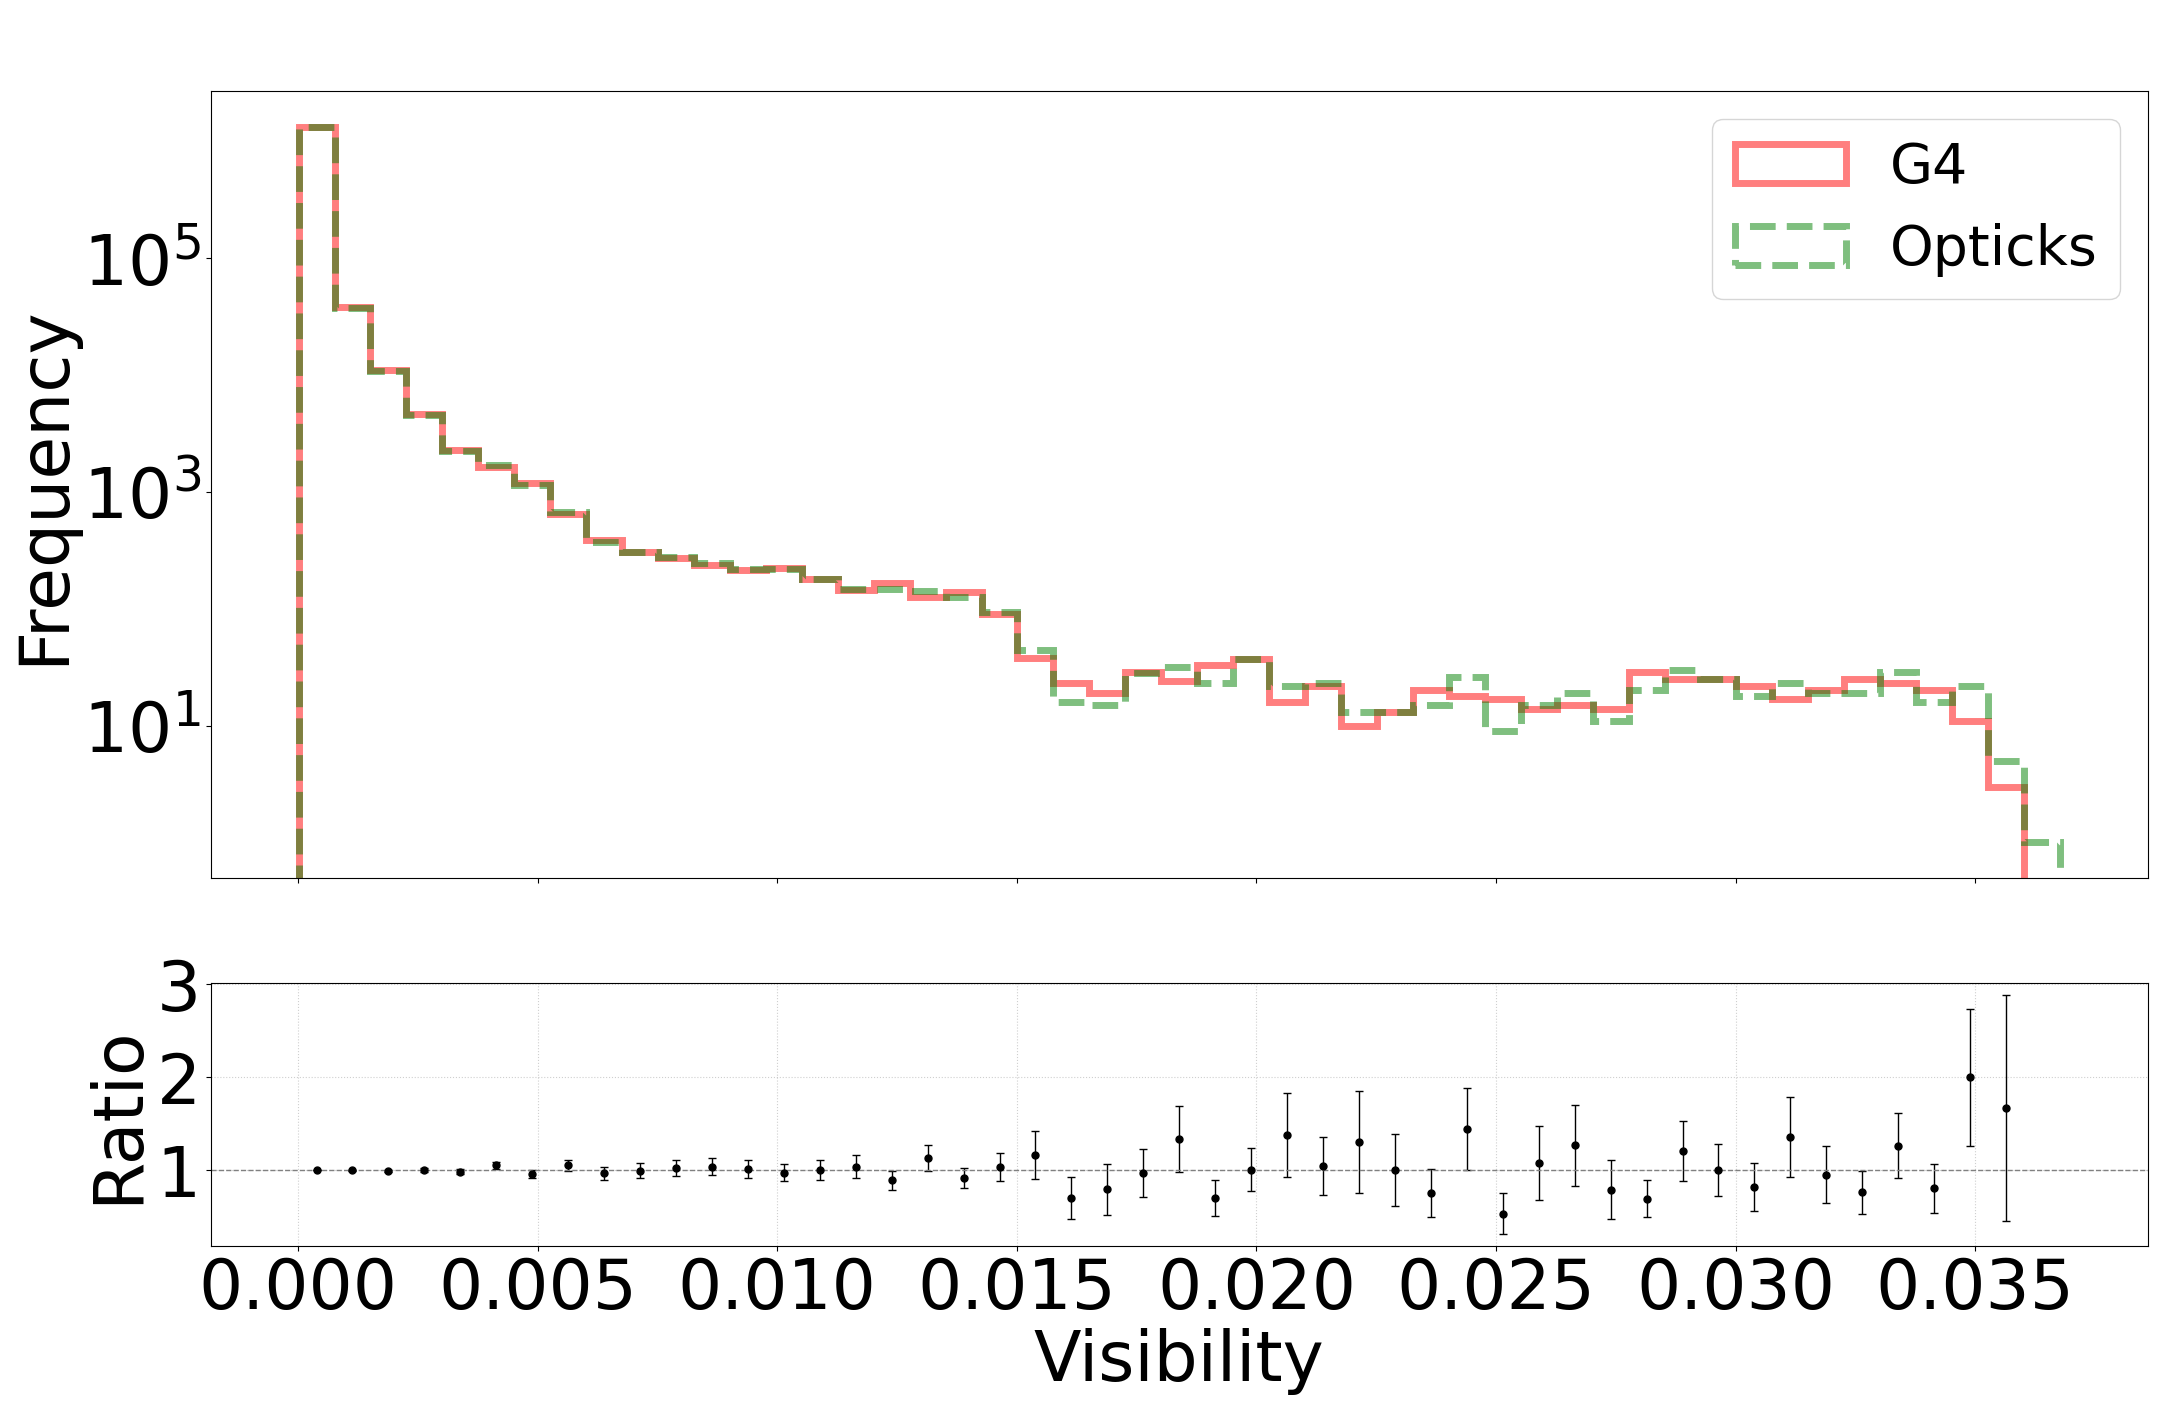

In [166]:
_=Plot1D_KDE(OVis[1],G4Vis[1],"Visibility_Comparison"," ",Binsize=50,labelx="Visibility",isPlottext=False,isHistType="",opacity=0.5,fontsize=40,width=5,lbls=["G4","Opticks"],tp="ratio",isLog=True,ylim=[],xlim=[])

 Size Bin_Centers is 99
 Size result 99 min, max nan , nan
 Size res_err 99 min, max nan , nan
 Max G4 1165255.0 O 1162586.0
 Min G4 0.0 O 0.0


/tmp/rice/opticks/ipykernel_1280218/1692060880.py:196: RuntimeWarning: divide by zero encountered in divide
  result  = counts2 / counts1
/tmp/rice/opticks/ipykernel_1280218/1692060880.py:196: RuntimeWarning: invalid value encountered in divide
  result  = counts2 / counts1
/tmp/rice/opticks/ipykernel_1280218/1692060880.py:198: RuntimeWarning: invalid value encountered in divide
  res_err = result * np.sqrt((err2 / counts2)**2 + (err1 / counts1)**2)


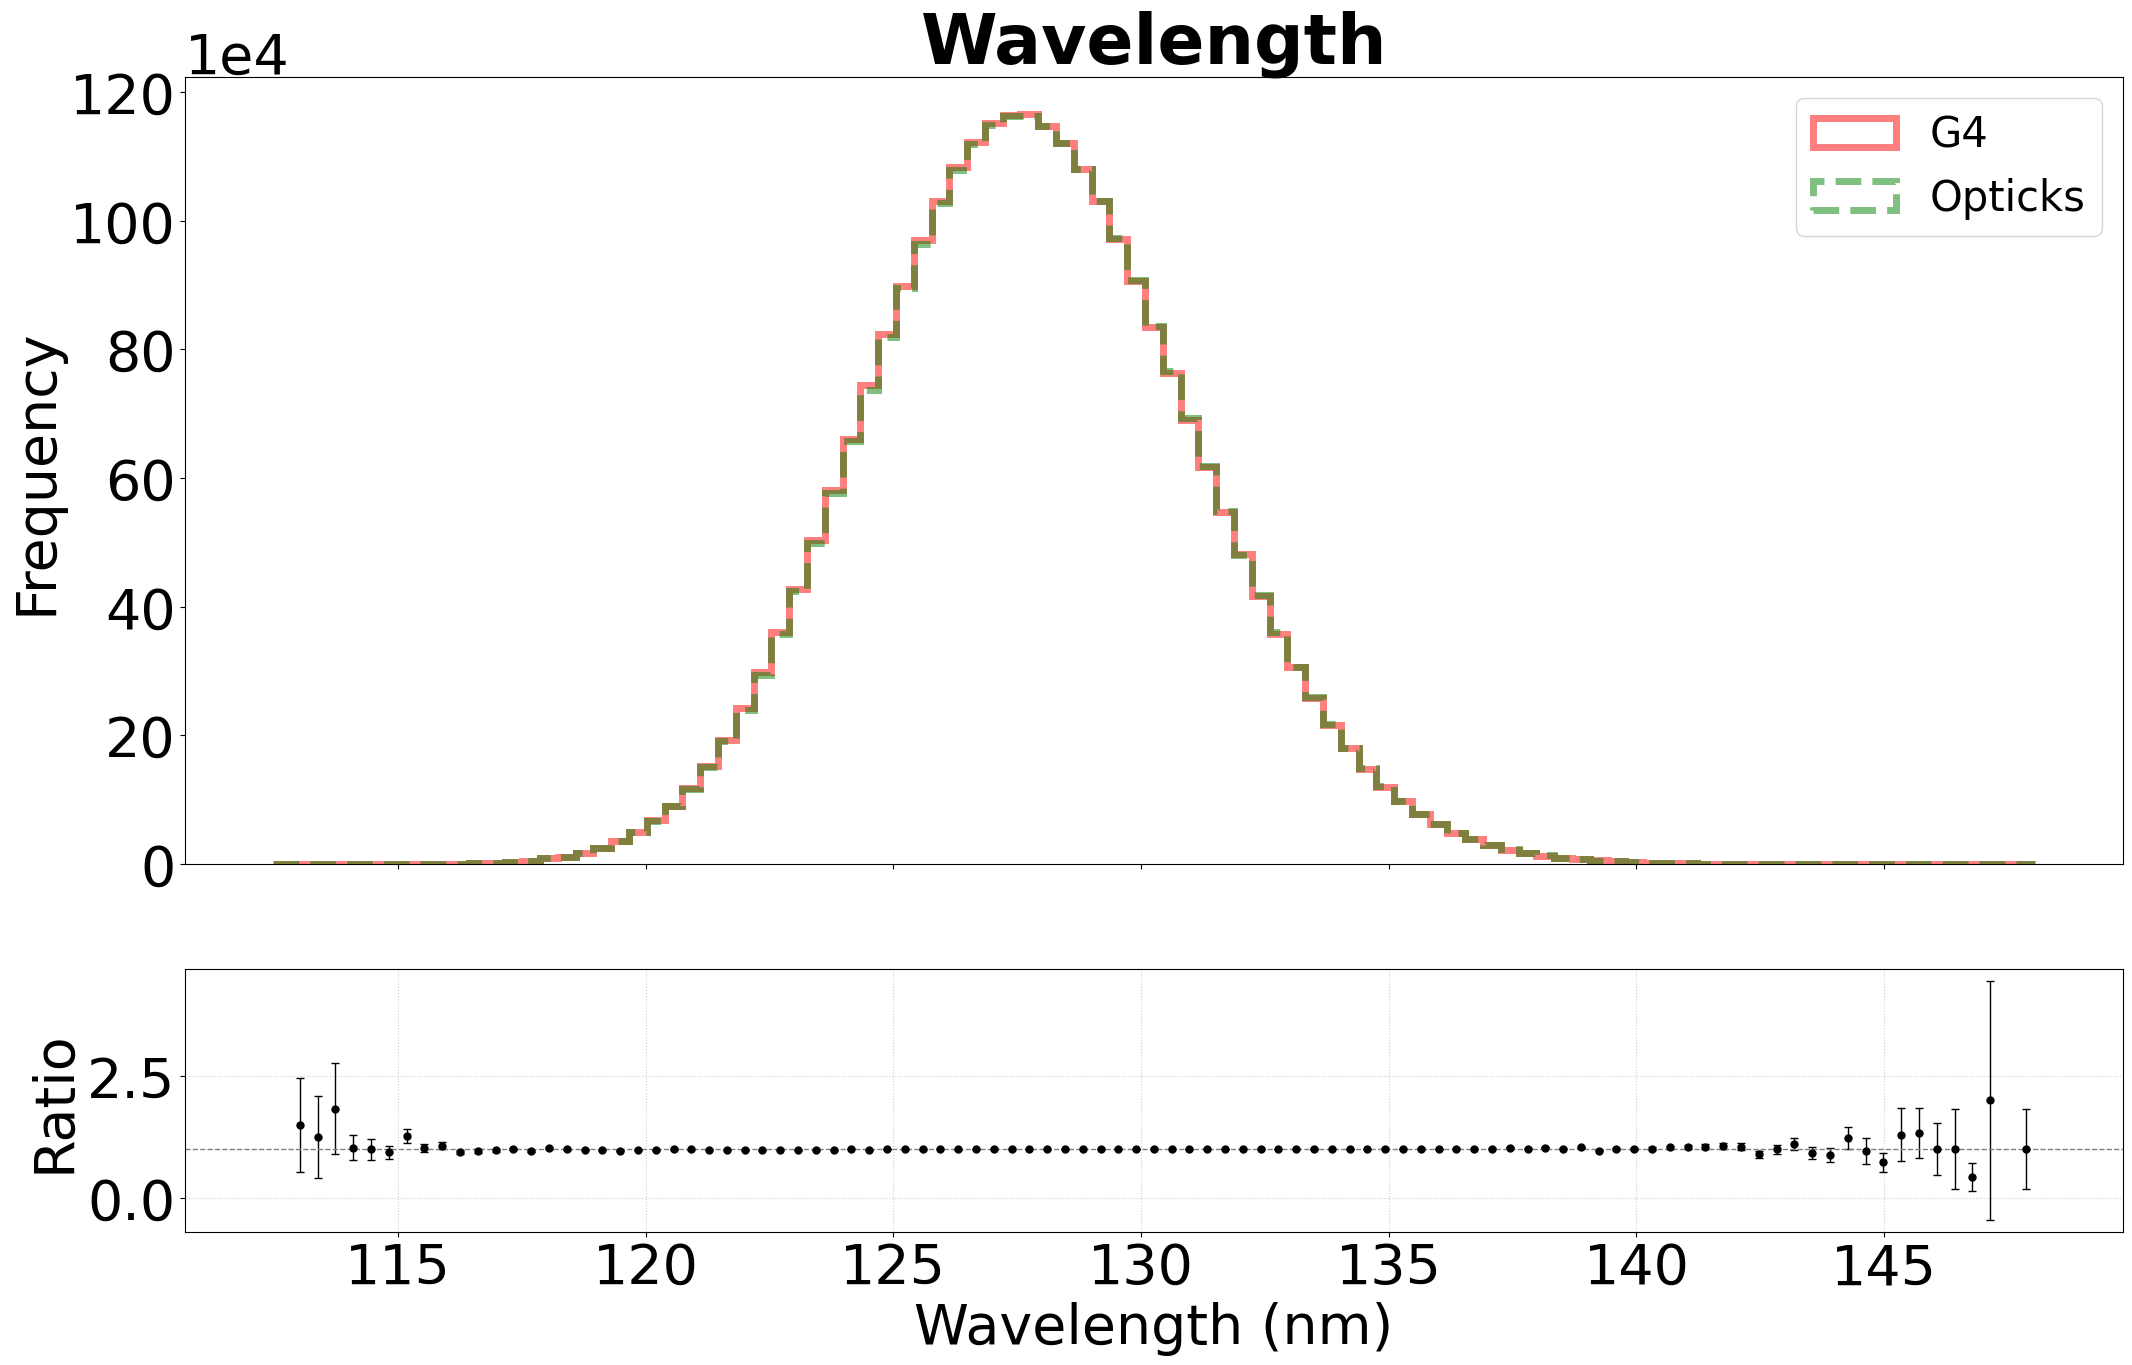

In [140]:

G4Wave = G4["wavelength"].array().to_numpy()
OpticksWave = Opticks["wavelength"].array().to_numpy()

xbins = np.linspace(xmin, xmax, 200)
_=Plot1D_KDE(OpticksWave,G4Wave,"Wavelength_Comparison","Wavelength",Binsize=100,labelx="Wavelength (nm)",isPlottext=False,isHistType="",opacity=0.5,fontsize=30,width=5,lbls=["G4","Opticks"],tp="ratio",isLog=False,ylim=[],xlim=[])

 Size Bin_Centers is 480
 Size result 480 min, max 1.023642351979983 , 0.9686525216961611
 Size res_err 480 min, max 0.01020713703574923 , 0.00523033343846639
 Max G4 72334.0 O 72534.0
 Min G4 19189.0 O 19063.0


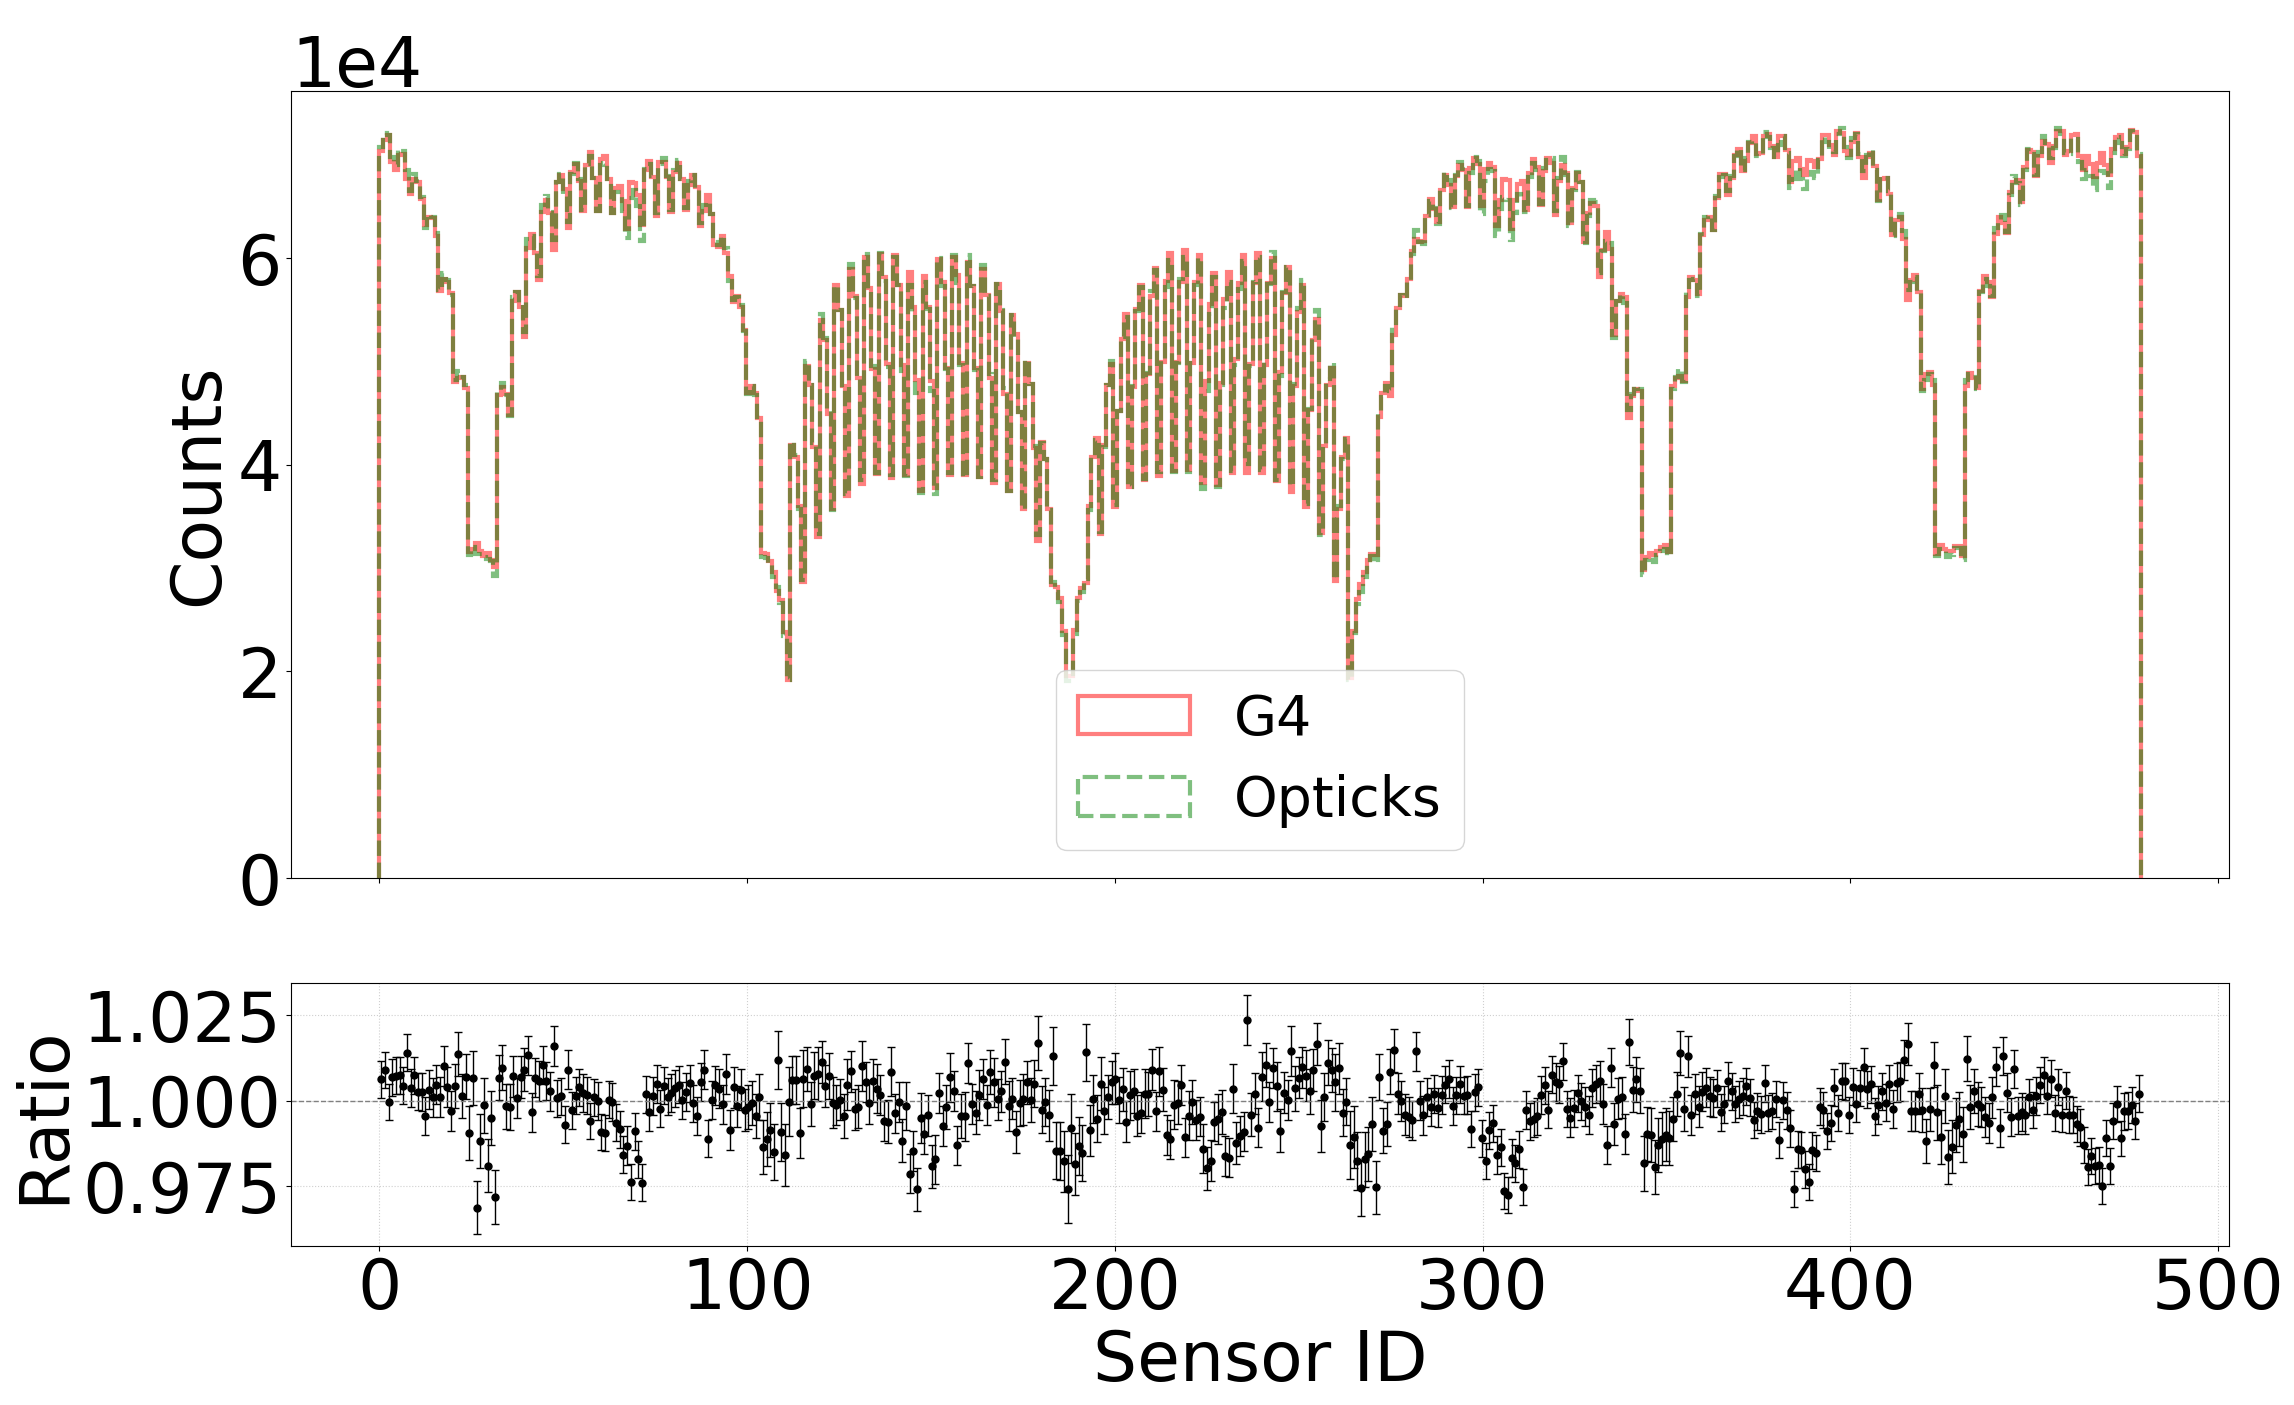

In [186]:

G4SID = G4["SensorID"].array().to_numpy()
OpticksSID = Opticks["SensorID"].array().to_numpy()

xbins = np.linspace(xmin, xmax, 480)
_=Plot1D_KDE(OpticksSID,G4SID,"Sensor ID Comparison"," ",Binsize=481,labelx="Sensor ID",isPlottext=False,isHistType="",opacity=0.5,fontsize=40,width=3,lbls=["G4","Opticks"],tp="ratio",isLog=False,ylim=[],xlim=[],Ylabel="Counts")